# MARID Flight Data Viewer
Visualize ESKF estimate vs Gazebo ground truth for any logged flight.

In [223]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FOLDER = 'data_extended'   # 'data' → old 12-col flights;  'data_extended' → rich feature flights
DATA_DIR = Path(f'../{DATA_FOLDER}')

# Discover available flights
all_files = sorted(DATA_DIR.glob('marid_eskf_gt_flight_*.npz'))
flights = sorted(set(
    f.name.split('_chunk')[0].replace('marid_eskf_gt_flight_', '')
    for f in all_files
))

print(f"Found {len(flights)/4} total base flights -> total {(len(flights))} mirrored flights included")
for i, fid in enumerate(flights):
    chunks = list(DATA_DIR.glob(f'marid_eskf_gt_flight_{fid}_chunk*.npz'))
    total = sum(int(np.load(c)['num_samples']) for c in chunks)
    print(f"  [{i:2d}] {fid}  ({len(chunks)} chunk(s), {total:,} samples)")

Found 51.0 total base flights -> total 204 mirrored flights included
  [ 0] 20260521_123357  (3 chunk(s), 25,647 samples)
  [ 1] 20260521_123357_combined_mirror  (3 chunk(s), 25,647 samples)
  [ 2] 20260521_123357_fore_aft_mirror  (3 chunk(s), 25,647 samples)
  [ 3] 20260521_123357_mirror  (3 chunk(s), 25,647 samples)
  [ 4] 20260521_135938  (4 chunk(s), 38,379 samples)
  [ 5] 20260521_135938_combined_mirror  (4 chunk(s), 38,379 samples)
  [ 6] 20260521_135938_fore_aft_mirror  (4 chunk(s), 38,379 samples)
  [ 7] 20260521_135938_mirror  (4 chunk(s), 38,379 samples)
  [ 8] 20260521_142637  (4 chunk(s), 31,806 samples)
  [ 9] 20260521_142637_combined_mirror  (4 chunk(s), 31,806 samples)
  [10] 20260521_142637_fore_aft_mirror  (4 chunk(s), 31,806 samples)
  [11] 20260521_142637_mirror  (4 chunk(s), 31,806 samples)
  [12] 20260521_211150  (3 chunk(s), 26,702 samples)
  [13] 20260521_211150_combined_mirror  (3 chunk(s), 26,702 samples)
  [14] 20260521_211150_fore_aft_mirror  (3 chunk(s), 26,

In [224]:
# ── Pick a flight ──────────────────────────────────────────────────────────────
FLIGHT_IDX = -4*1   # change to any index above, or set FLIGHT_ID directly
FLIGHT_ID  = flights[FLIGHT_IDX]
print(f"Loading flight: {FLIGHT_ID}")

chunks = sorted(DATA_DIR.glob(f'marid_eskf_gt_flight_{FLIGHT_ID}_chunk*.npz'))
est = np.concatenate([np.load(c)['eskf_inputs']  for c in chunks])  # (N,12)
gt  = np.concatenate([np.load(c)['pose_targets']  for c in chunks])  # (N,7) or (N,9)

def _load_optional_1d(key):
    pieces = []
    for c in chunks:
        arr = np.load(c, allow_pickle=True)
        if key not in arr:
            return None
        pieces.append(arr[key].astype(np.float32))
    return np.concatenate(pieces) if pieces else None

eskf_horizontal_heading = _load_optional_1d('eskf_horizontal_heading')
target_horizontal_heading = _load_optional_1d('target_horizontal_heading')
has_horizontal_heading = (
    eskf_horizontal_heading is not None
    and target_horizontal_heading is not None
    and len(eskf_horizontal_heading) == len(est)
    and len(target_horizontal_heading) == len(est)
)

N   = len(est)
t   = np.arange(N) / 50.0   # logged at 50 Hz → seconds

EST_ALL = ['x','y','z','roll','pitch','yaw','vx','vy','vz','p','q','r']

if gt.shape[1] == 7:
    GT_COLS = ['x','y','roll','pitch','yaw','vx','vy']
    units   = ['m','m','rad','rad','rad','m/s','m/s']
else:
    GT_COLS = ['x','y','z','roll','pitch','yaw','vx','vy','vz']
    units   = ['m','m','m','rad','rad','rad','m/s','m/s','m/s']

# For each GT column, the corresponding index in est
est_idx  = [EST_ALL.index(c) for c in GT_COLS]

pos_cols = [(i, c) for i, c in enumerate(GT_COLS) if c in ('x','y','z')]
att_cols = [(i, c) for i, c in enumerate(GT_COLS) if c in ('roll','pitch','yaw')]
vel_cols = [(i, c) for i, c in enumerate(GT_COLS) if c in ('vx','vy','vz')]

print(f"  {N:,} samples  ({t[-1]:.1f} s)")
print(f"  GT columns ({gt.shape[1]}): {GT_COLS}")
print(f"  Horizontal heading sidecars: {'yes' if has_horizontal_heading else 'no'}")

Loading flight: 20260526_104336
  10,168 samples  (203.3 s)
  GT columns (7): ['x', 'y', 'roll', 'pitch', 'yaw', 'vx', 'vy']
  Horizontal heading sidecars: yes


## Position (x, y, z)

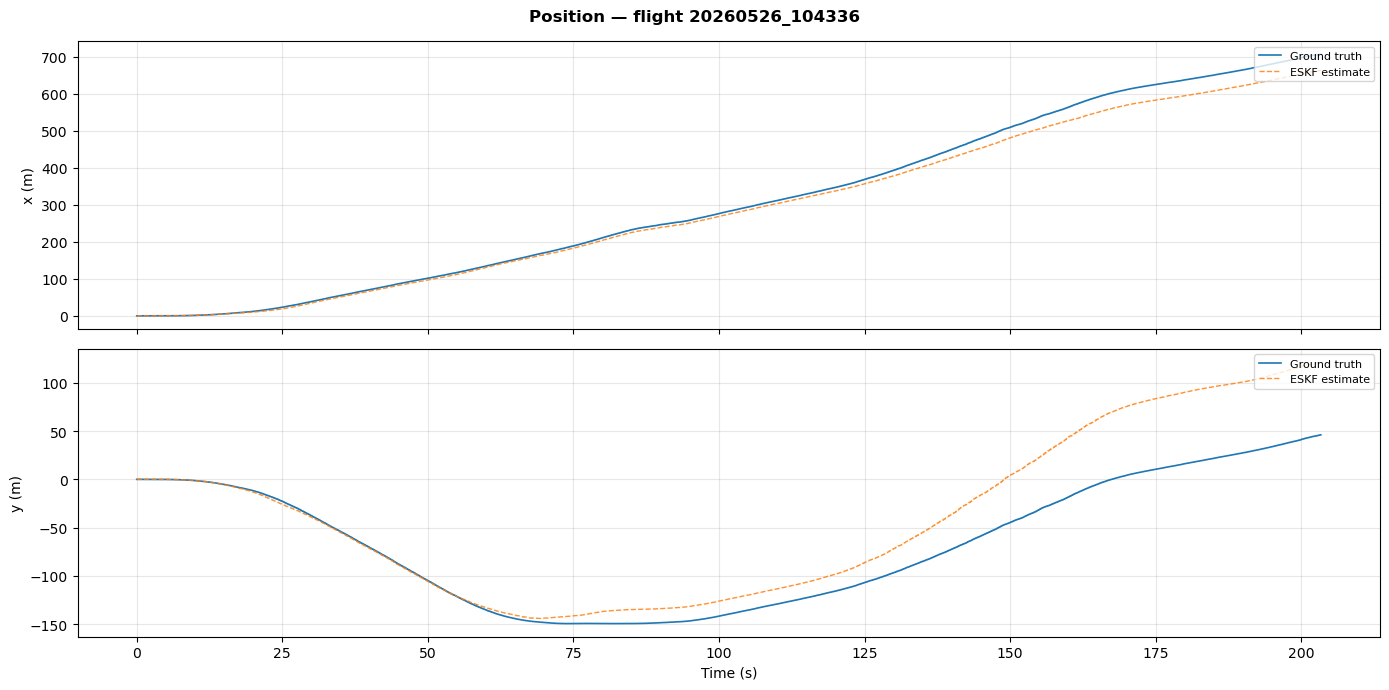

In [225]:
fig, axes = plt.subplots(len(pos_cols), 1, figsize=(14, 3 * len(pos_cols) + 1), sharex=True)
if len(pos_cols) == 1: axes = [axes]
for ax, (gi, col) in zip(axes, pos_cols):
    ax.plot(t, gt[:, gi],           label='Ground truth', linewidth=1.2)
    ax.plot(t, est[:, est_idx[gi]], label='ESKF estimate', linewidth=1.0, alpha=0.85, linestyle='--')
    ax.set_ylabel(f'{col} (m)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Position — flight {FLIGHT_ID}', fontweight='bold')
plt.tight_layout()
plt.show()

## Attitude (roll, pitch, yaw)

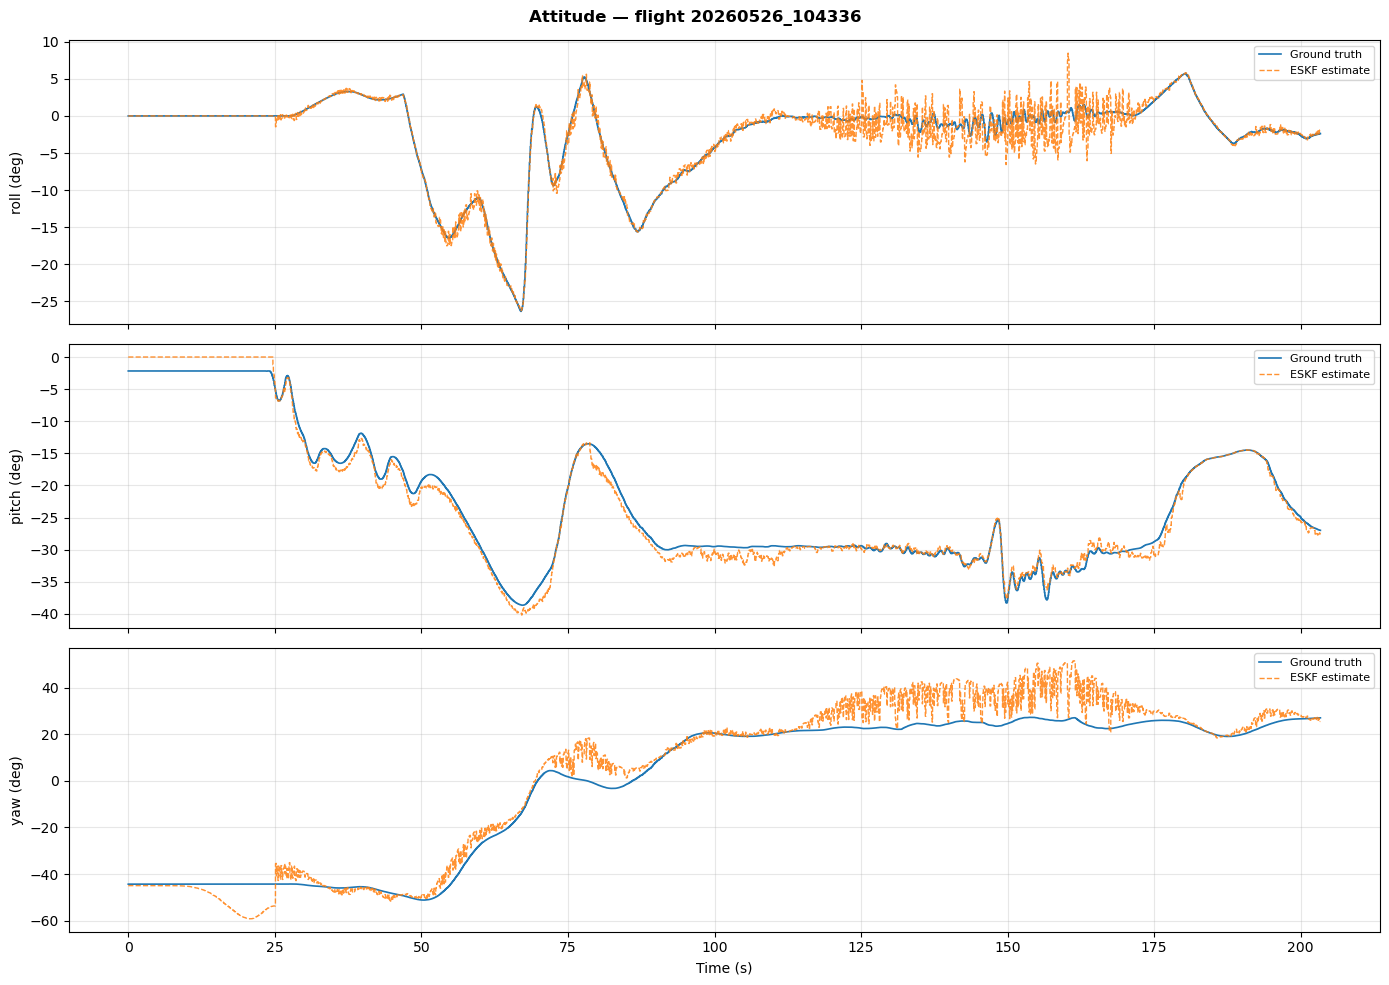

In [226]:
fig, axes = plt.subplots(len(att_cols), 1, figsize=(14, 3 * len(att_cols) + 1), sharex=True)
if len(att_cols) == 1: axes = [axes]
for ax, (gi, col) in zip(axes, att_cols):
    ax.plot(t, np.degrees(gt[:, gi]),           label='Ground truth', linewidth=1.2)
    ax.plot(t, np.degrees(est[:, est_idx[gi]]), label='ESKF estimate', linewidth=1.0, alpha=0.85, linestyle='--')
    ax.set_ylabel(f'{col} (deg)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Attitude — flight {FLIGHT_ID}', fontweight='bold')
plt.tight_layout()
plt.show()

## Heading Diagnostics

Projected attitude heading is mostly equivalent to Euler yaw for normal pitch angles. Ground-track course from vx/vy is included to expose yaw/velocity-frame corruption.

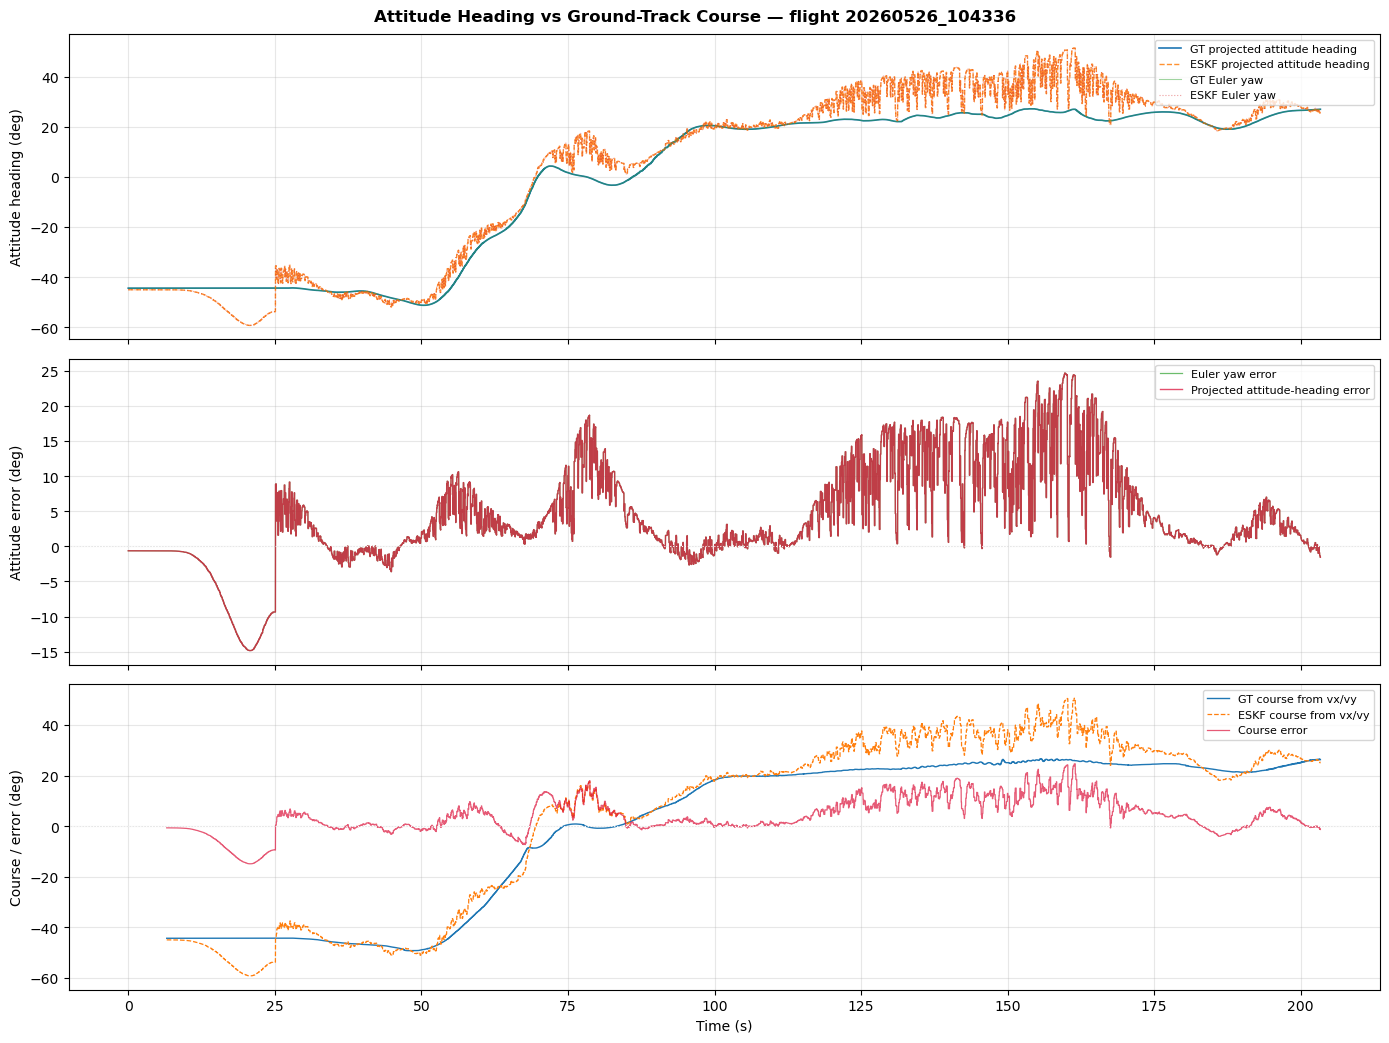

Yaw/heading/course error summary (deg):
  Euler yaw                    RMSE=   8.32  meanAE=   5.86  maxAE=  24.71
  Projected attitude heading   RMSE=   8.32  meanAE=   5.86  maxAE=  24.71
  Max projected-heading minus Euler-yaw delta: 0.000000 deg
  Ground-track course          RMSE=   8.02  meanAE=   6.00  maxAE=  24.70  (9,840 samples > 1 m/s)


In [227]:
# ── Horizontal-projected attitude heading + ground-track course ───────────────
_wrap = lambda a: (a + np.pi) % (2 * np.pi) - np.pi

yaw_gi = GT_COLS.index('yaw')
yaw_ei = est_idx[yaw_gi]
euler_yaw_err = _wrap(est[:, yaw_ei] - gt[:, yaw_gi])

if has_horizontal_heading:
    horiz_heading_err = _wrap(eskf_horizontal_heading - target_horizontal_heading)
    heading_yaw_delta = np.degrees(np.max(np.abs(_wrap(eskf_horizontal_heading - est[:, yaw_ei]))))
else:
    horiz_heading_err = None
    heading_yaw_delta = None

has_course = all(c in GT_COLS for c in ('vx', 'vy'))
if has_course:
    vx_gi, vy_gi = GT_COLS.index('vx'), GT_COLS.index('vy')
    vx_ei, vy_ei = est_idx[vx_gi], est_idx[vy_gi]
    gt_speed_xy = np.hypot(gt[:, vx_gi], gt[:, vy_gi])
    est_speed_xy = np.hypot(est[:, vx_ei], est[:, vy_ei])
    course_mask = (gt_speed_xy > 1.0) & (est_speed_xy > 1.0)
    gt_course = np.arctan2(gt[:, vy_gi], gt[:, vx_gi])
    eskf_course = np.arctan2(est[:, vy_ei], est[:, vx_ei])
    course_err = _wrap(eskf_course - gt_course)
else:
    course_mask = None

n_rows = 3 if has_course else 2
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3.2 * n_rows + 1), sharex=True)

if has_horizontal_heading:
    axes[0].plot(t, np.degrees(target_horizontal_heading), label='GT projected attitude heading', linewidth=1.2)
    axes[0].plot(t, np.degrees(eskf_horizontal_heading), label='ESKF projected attitude heading', linewidth=1.0, alpha=0.85, linestyle='--')
else:
    axes[0].text(0.5, 0.5, 'No horizontal heading sidecars in this flight', ha='center', va='center', transform=axes[0].transAxes)
axes[0].plot(t, np.degrees(gt[:, yaw_gi]), label='GT Euler yaw', linewidth=0.8, alpha=0.45)
axes[0].plot(t, np.degrees(est[:, yaw_ei]), label='ESKF Euler yaw', linewidth=0.8, alpha=0.45, linestyle=':')
axes[0].set_ylabel('Attitude heading (deg)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, np.degrees(euler_yaw_err), label='Euler yaw error', linewidth=0.9, color='tab:green', alpha=0.7)
if has_horizontal_heading:
    axes[1].plot(t, np.degrees(horiz_heading_err), label='Projected attitude-heading error', linewidth=1.0, color='crimson', alpha=0.75)
axes[1].axhline(0, color='white', linewidth=0.8, linestyle=':')
axes[1].set_ylabel('Attitude error (deg)')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

if has_course:
    axes[2].plot(t[course_mask], np.degrees(gt_course[course_mask]), label='GT course from vx/vy', linewidth=1.0)
    axes[2].plot(t[course_mask], np.degrees(eskf_course[course_mask]), label='ESKF course from vx/vy', linewidth=0.9, linestyle='--')
    axes[2].plot(t[course_mask], np.degrees(course_err[course_mask]), label='Course error', linewidth=0.9, color='crimson', alpha=0.7)
    axes[2].axhline(0, color='white', linewidth=0.8, linestyle=':')
    axes[2].set_ylabel('Course / error (deg)')
    axes[2].set_xlabel('Time (s)')
    axes[2].legend(loc='upper right', fontsize=8)
    axes[2].grid(True, alpha=0.3)
else:
    axes[-1].set_xlabel('Time (s)')

fig.suptitle(f'Attitude Heading vs Ground-Track Course — flight {FLIGHT_ID}', fontweight='bold')
plt.tight_layout()
plt.show()

print('Yaw/heading/course error summary (deg):')
abs_deg = np.abs(np.degrees(euler_yaw_err))
print(f"  {'Euler yaw':<28} RMSE={np.sqrt(np.mean(abs_deg**2)):7.2f}  meanAE={np.mean(abs_deg):7.2f}  maxAE={np.max(abs_deg):7.2f}")
if has_horizontal_heading:
    abs_deg = np.abs(np.degrees(horiz_heading_err))
    print(f"  {'Projected attitude heading':<28} RMSE={np.sqrt(np.mean(abs_deg**2)):7.2f}  meanAE={np.mean(abs_deg):7.2f}  maxAE={np.max(abs_deg):7.2f}")
    print(f"  Max projected-heading minus Euler-yaw delta: {heading_yaw_delta:.6f} deg")
if has_course and np.any(course_mask):
    abs_deg = np.abs(np.degrees(course_err[course_mask]))
    print(f"  {'Ground-track course':<28} RMSE={np.sqrt(np.mean(abs_deg**2)):7.2f}  meanAE={np.mean(abs_deg):7.2f}  maxAE={np.max(abs_deg):7.2f}  ({course_mask.sum():,} samples > 1 m/s)")

## Altitude, Thrust & Attitude Error

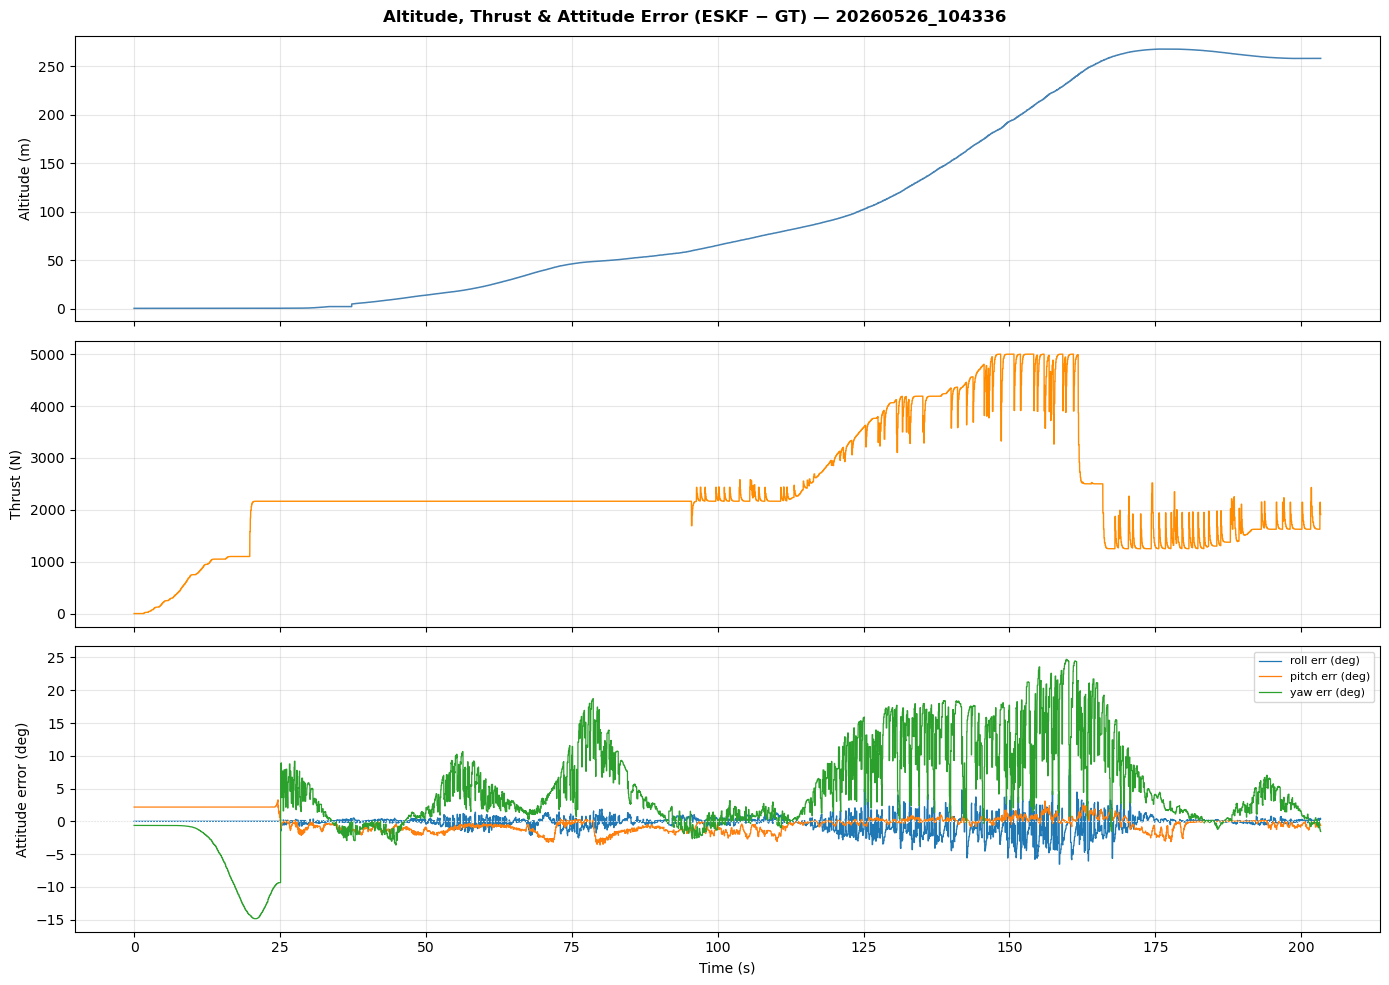

In [228]:
# ── Altitude (ESKF z) & Thrust / Attitude Error ──────────────────────────────
_wrap = lambda a: (a + np.pi) % (2 * np.pi) - np.pi

thrust_pieces = []
for c in chunks:
    arr = np.load(c, allow_pickle=True)
    if 'thrust' in arr:
        thrust_pieces.append(arr['thrust'].astype(np.float32))
thrust_data = np.concatenate(thrust_pieces) if len(thrust_pieces) == len(chunks) else None

n_rows = 3 if thrust_data is not None else 2
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows + 1), sharex=True)

ax_z = axes[0]
ax_z.plot(t, est[:, 2], linewidth=1.1, color='steelblue', label='ESKF z')
if 'z' in GT_COLS:
    zi = GT_COLS.index('z')
    ax_z.plot(t, gt[:, zi], linewidth=1.1, color='tomato', linestyle='--', label='GT z')
    ax_z.legend(fontsize=8)
ax_z.set_ylabel('Altitude (m)')
ax_z.grid(True, alpha=0.3)

if thrust_data is not None:
    ax_t = axes[1]
    ax_t.plot(t, thrust_data, linewidth=1.0, color='darkorange')
    ax_t.set_ylabel('Thrust (N)')
    ax_t.grid(True, alpha=0.3)
    ax_e = axes[2]
else:
    ax_e = axes[1]

_att_err_cols = {
    col: (color, est_idx[GT_COLS.index(col)], GT_COLS.index(col))
    for col, color in [('roll', 'tab:blue'), ('pitch', 'tab:orange'), ('yaw', 'tab:green')]
    if col in GT_COLS
}
for col, (color, ei, gi) in _att_err_cols.items():
    ax_e.plot(t, np.degrees(_wrap(est[:, ei] - gt[:, gi])),
              label=f'{col} err (deg)', linewidth=0.9, color=color)
ax_e.axhline(0, color='white', linewidth=0.8, linestyle=':')
ax_e.set_ylabel('Attitude error (deg)')
ax_e.set_xlabel('Time (s)')
ax_e.legend(loc='upper right', fontsize=8)
ax_e.grid(True, alpha=0.3)

fig.suptitle(f'Altitude, Thrust & Attitude Error (ESKF − GT) — {FLIGHT_ID}', fontweight='bold')
plt.tight_layout()
plt.show()

## Velocity (vx, vy, vz)

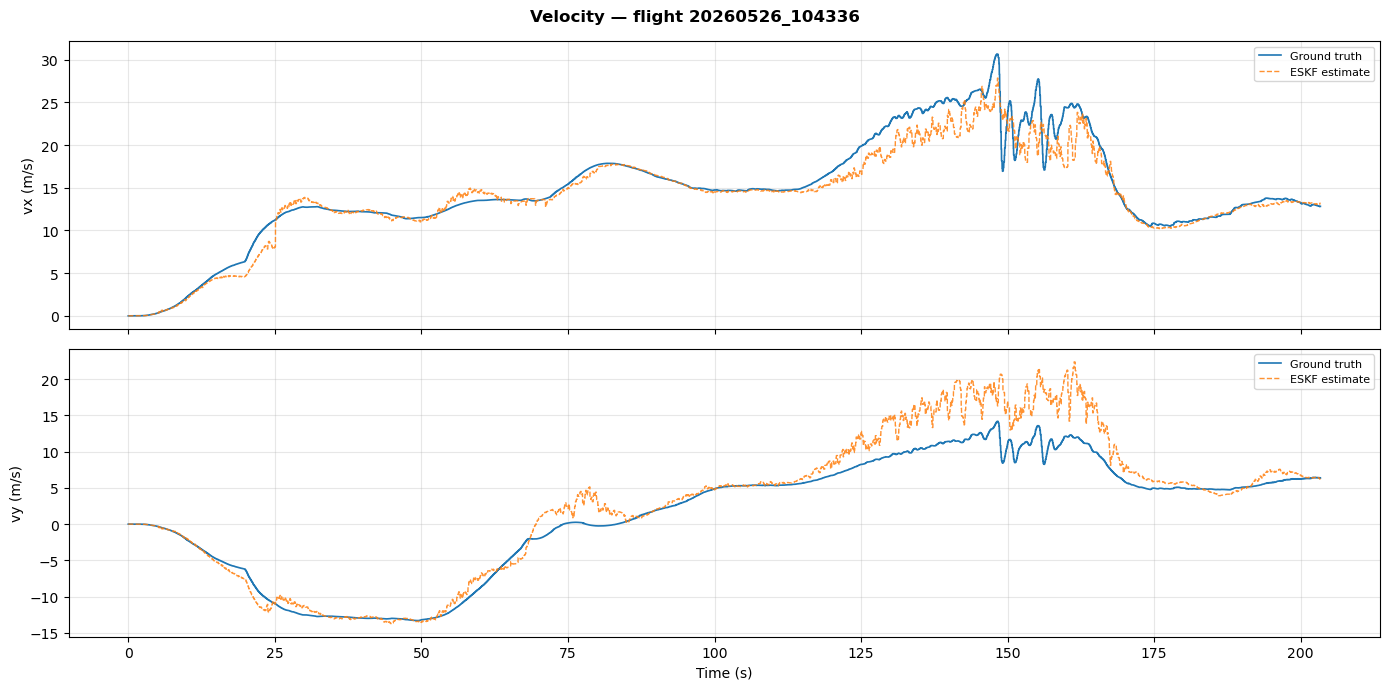

In [229]:
fig, axes = plt.subplots(len(vel_cols), 1, figsize=(14, 3 * len(vel_cols) + 1), sharex=True)
if len(vel_cols) == 1: axes = [axes]
for ax, (gi, col) in zip(axes, vel_cols):
    ax.plot(t, gt[:, gi],           label='Ground truth', linewidth=1.2)
    ax.plot(t, est[:, est_idx[gi]], label='ESKF estimate', linewidth=1.0, alpha=0.85, linestyle='--')
    ax.set_ylabel(f'{col} (m/s)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Velocity — flight {FLIGHT_ID}', fontweight='bold')
plt.tight_layout()
plt.show()

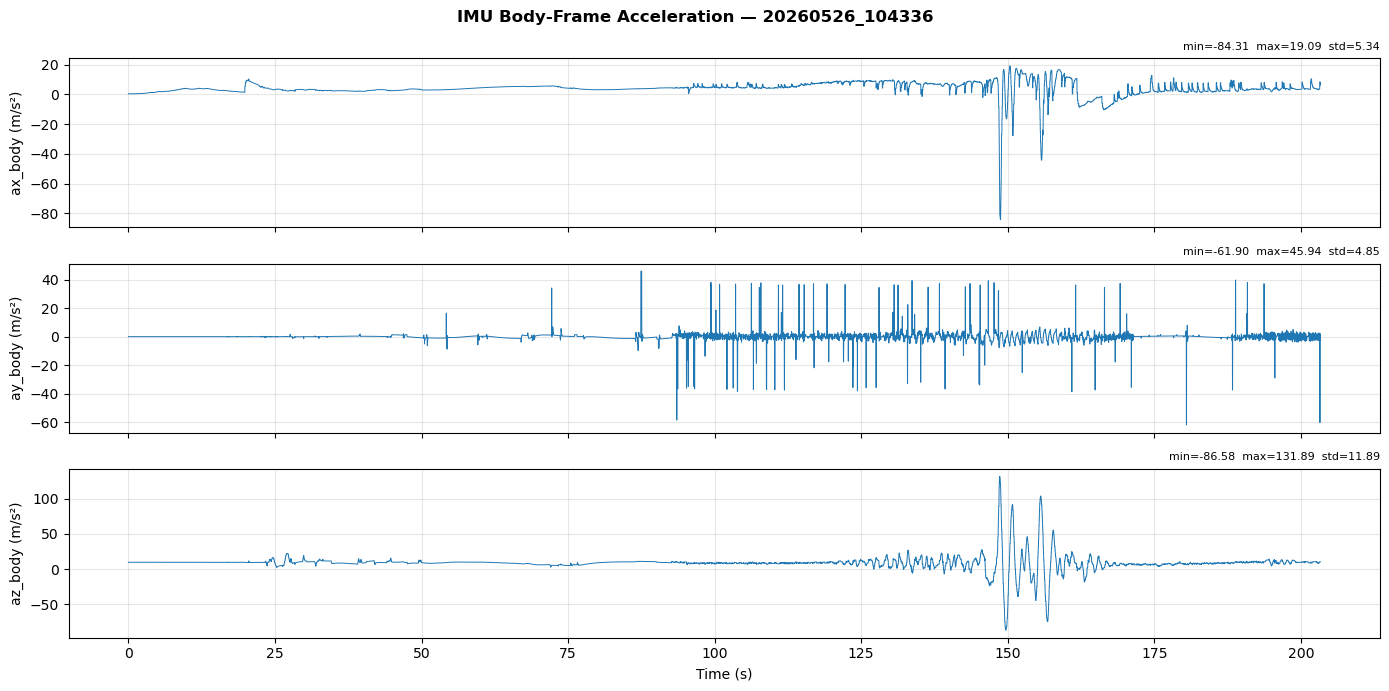

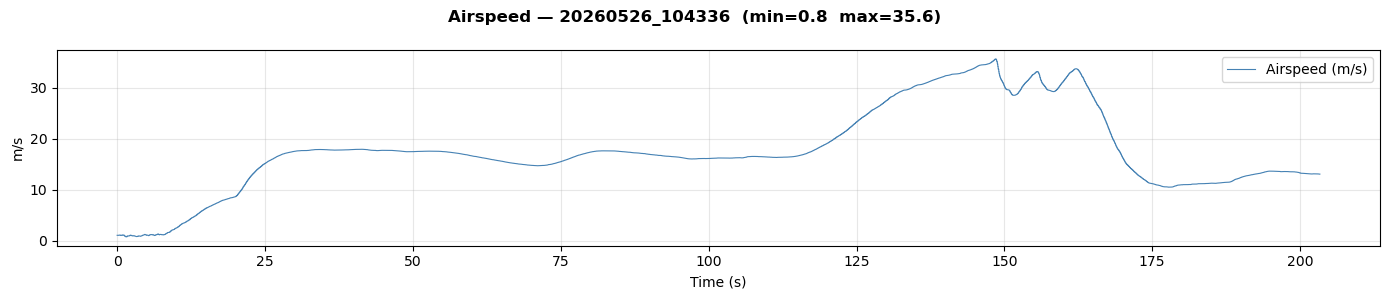

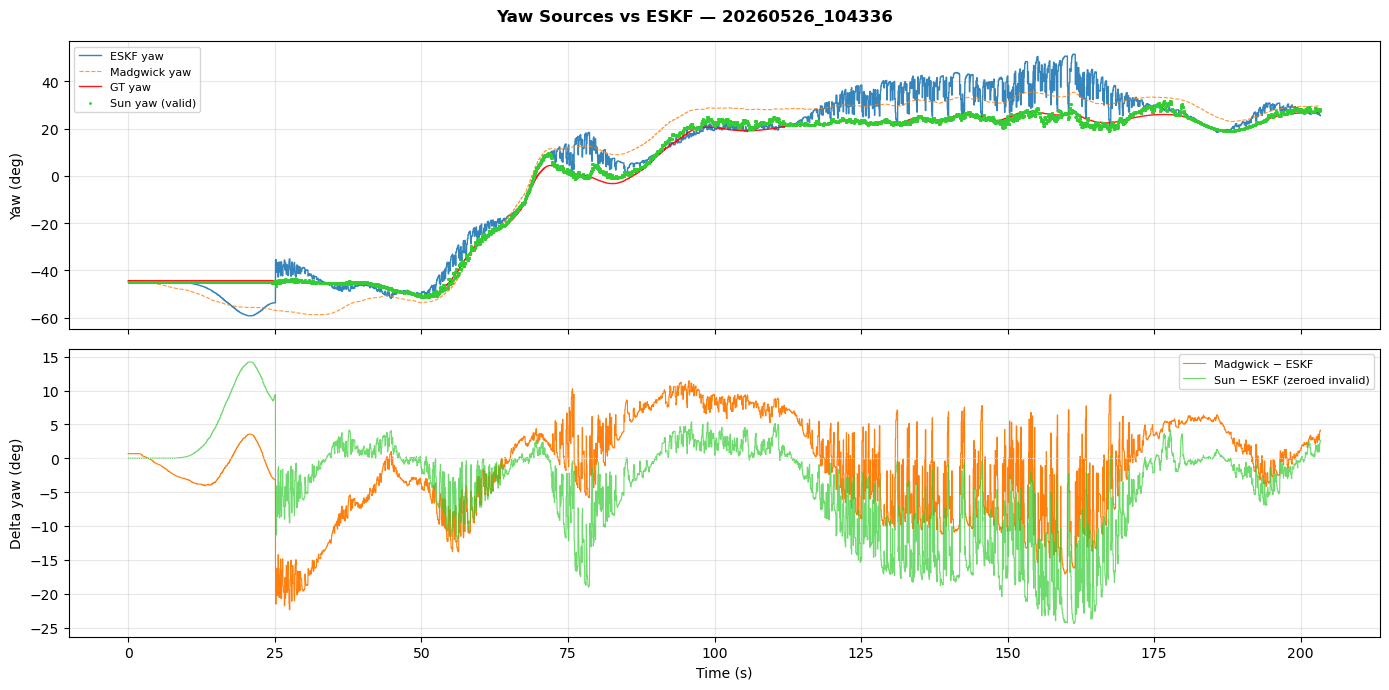

Extended channel summary:
  imu_acc     ax: [-84.31, 19.09]  ay: [-61.90, 45.94]  az: [-86.58, 131.89]
  airspeed    [0.8, 35.6] m/s
  sun_valid   100.0% of samples
  Δyaw_sun    mean=-3.74°  std=7.46°  max|Δ|=24.42°
  Δyaw_madg   mean=-1.17°  std=6.89°  max|Δ|=22.35°


In [230]:
def _load_ext(key, shape2d=False):
    pieces = []
    for c in chunks:
        arr = np.load(c, allow_pickle=True)
        if key not in arr:
            return None
        pieces.append(arr[key].astype(np.float32))
    if not pieces:
        return None
    out = np.concatenate(pieces)
    return out

_wrap = lambda a: (a + np.pi) % (2 * np.pi) - np.pi

imu_acc      = _load_ext('imu_acc')       # (N, 3)
yaw_madgwick = _load_ext('yaw_madgwick')  # (N,)
airspeed     = _load_ext('airspeed')      # (N,)
sun_yaw      = _load_ext('sun_yaw')       # (N,)
sun_valid    = _load_ext('sun_valid')     # (N,)

if imu_acc is None:
    print('No extended arrays found — run with data_extended flights.')
else:
    yaw_eskf = est[:, 5]
    yaw_gi   = GT_COLS.index('yaw')

    # ── IMU acceleration ──────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
    for ax, col, lbl in zip(axes, range(3), ['ax_body (m/s²)', 'ay_body (m/s²)', 'az_body (m/s²)']):
        ax.plot(t, imu_acc[:, col], linewidth=0.7)
        ax.set_ylabel(lbl); ax.grid(True, alpha=0.3)
        ax.set_title(f'  min={imu_acc[:,col].min():.2f}  max={imu_acc[:,col].max():.2f}  std={imu_acc[:,col].std():.2f}', fontsize=8, loc='right')
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'IMU Body-Frame Acceleration — {FLIGHT_ID}', fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── Airspeed ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(t, airspeed, linewidth=0.8, color='steelblue', label='Airspeed (m/s)')
    ax.set_ylabel('m/s'); ax.set_xlabel('Time (s)'); ax.legend(); ax.grid(True, alpha=0.3)
    fig.suptitle(f'Airspeed — {FLIGHT_ID}  (min={airspeed.min():.1f}  max={airspeed.max():.1f})', fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── Yaw sources vs ESKF ───────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(t, np.degrees(yaw_eskf),       linewidth=1.0, label='ESKF yaw',     alpha=0.9)
    axes[0].plot(t, np.degrees(yaw_madgwick),   linewidth=0.8, label='Madgwick yaw', alpha=0.8, linestyle='--')
    axes[0].plot(t, np.degrees(gt[:, yaw_gi]),  linewidth=1.0, label='GT yaw',       alpha=0.9, color='red')
    if sun_valid is not None and sun_valid.max() > 0:
        sv = sun_valid.astype(bool)
        axes[0].scatter(t[sv], np.degrees(sun_yaw[sv]), s=1, color='limegreen', label='Sun yaw (valid)', zorder=3)
    axes[0].set_ylabel('Yaw (deg)'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, np.degrees(_wrap(yaw_madgwick - yaw_eskf)),
                 linewidth=0.8, label='Madgwick − ESKF', color='tab:orange')
    if sun_valid is not None and sun_valid.max() > 0:
        delta_sun = np.degrees(_wrap(sun_yaw - yaw_eskf)) * sun_valid
        axes[1].plot(t, delta_sun, linewidth=0.8, label='Sun − ESKF (zeroed invalid)', color='limegreen', alpha=0.7)
    axes[1].axhline(0, color='white', linewidth=0.6, linestyle=':')
    axes[1].set_ylabel('Delta yaw (deg)'); axes[1].set_xlabel('Time (s)')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    fig.suptitle(f'Yaw Sources vs ESKF — {FLIGHT_ID}', fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── Availability summary ──────────────────────────────────────────────
    print('Extended channel summary:')
    print(f'  imu_acc     ax: [{imu_acc[:,0].min():.2f}, {imu_acc[:,0].max():.2f}]  '
          f'ay: [{imu_acc[:,1].min():.2f}, {imu_acc[:,1].max():.2f}]  '
          f'az: [{imu_acc[:,2].min():.2f}, {imu_acc[:,2].max():.2f}]')
    print(f'  airspeed    [{airspeed.min():.1f}, {airspeed.max():.1f}] m/s')
    print(f'  sun_valid   {sun_valid.mean()*100:.1f}% of samples')
    if sun_valid.max() > 0:
        ds = np.degrees(_wrap(sun_yaw[sun_valid.astype(bool)] - yaw_eskf[sun_valid.astype(bool)]))
        print(f'  Δyaw_sun    mean={ds.mean():.2f}°  std={ds.std():.2f}°  max|Δ|={np.abs(ds).max():.2f}°')
    dm2 = np.degrees(_wrap(yaw_madgwick - yaw_eskf))
    print(f'  Δyaw_madg   mean={dm2.mean():.2f}°  std={dm2.std():.2f}°  max|Δ|={np.abs(dm2).max():.2f}°')

## Extended Sensor Channels (data_extended only)

## 2D Trajectory (top-down)

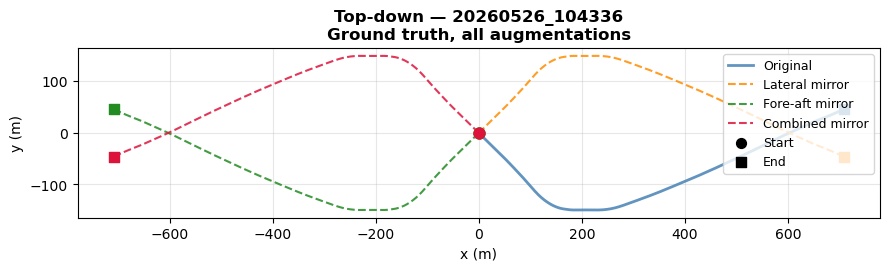

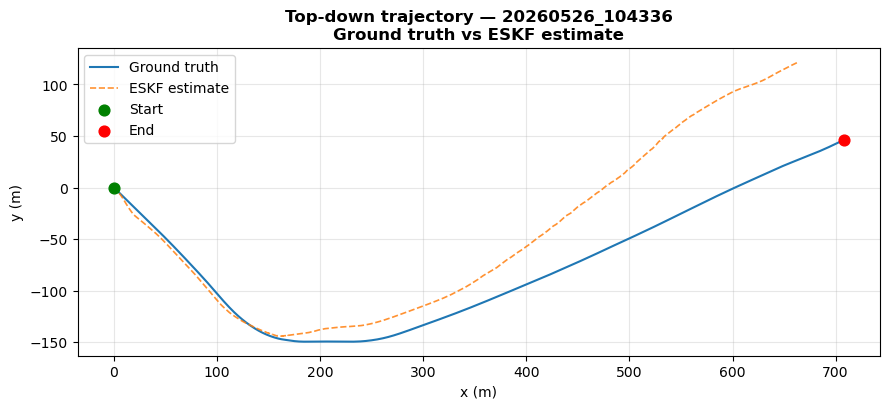

In [231]:

# ── Plot 1: all 4 augmentation variants (ground truth only) ───────────────────
base_id = FLIGHT_ID
for suffix in ('_combined_mirror', '_fore_aft_mirror', '_mirror'):
    if base_id.endswith(suffix):
        base_id = base_id[:-len(suffix)]
        break

variants = [
    (base_id,                      'Original',        'steelblue',  '-',   2.0),
    (base_id + '_mirror',          'Lateral mirror',  'darkorange', '--',  1.5),
    (base_id + '_fore_aft_mirror', 'Fore-aft mirror', 'forestgreen','--',  1.5),
    (base_id + '_combined_mirror', 'Combined mirror', 'crimson',    '--',  1.5),
]

fig1, ax1 = plt.subplots(figsize=(9, 8))
for fid, label, color, ls, lw in variants:
    chunks = sorted(DATA_DIR.glob(f'marid_eskf_gt_flight_{fid}_chunk*.npz'))
    if not chunks:
        print(f'  {label}: no data found ({fid})')
        continue
    g = np.concatenate([np.load(c)['pose_targets'] for c in chunks])
    ax1.plot(g[:, 0], g[:, 1], color=color, linestyle=ls, linewidth=lw, label=label, alpha=0.85)
    ax1.scatter(g[0, 0],  g[0, 1],  color=color, marker='o', s=60, zorder=5)
    ax1.scatter(g[-1, 0], g[-1, 1], color=color, marker='s', s=60, zorder=5)

ax1.scatter([], [], color='k', marker='o', s=50, label='Start')
ax1.scatter([], [], color='k', marker='s', s=50, label='End')
ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)')
ax1.set_aspect('equal'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_title(f'Top-down — {base_id}\nGround truth, all augmentations', fontweight='bold')
plt.tight_layout(); plt.show()

# ── Plot 2: selected flight — ESKF estimate vs ground truth ───────────────────
fig2, ax2 = plt.subplots(figsize=(9, 7))
ax2.plot(gt[:, 0],  gt[:, 1],  label='Ground truth', linewidth=1.5)
ax2.plot(est[:, 0], est[:, 1], label='ESKF estimate', linewidth=1.2, linestyle='--', alpha=0.85)
ax2.scatter(*gt[0, :2],  color='green', zorder=5, s=60, label='Start')
ax2.scatter(*gt[-1, :2], color='red',   zorder=5, s=60, label='End')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')
ax2.set_aspect('equal'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_title(f'Top-down trajectory — {FLIGHT_ID}\nGround truth vs ESKF estimate', fontweight='bold')
plt.tight_layout(); plt.show()


## Error summary

In [232]:
_ANGLE_COLS = {'roll', 'pitch', 'yaw'}

def _wrap(a):
    """Wrap angle difference to [-π, π]."""
    return (a + np.pi) % (2 * np.pi) - np.pi

err = np.zeros((N, len(GT_COLS)), dtype=np.float32)
for i, col in enumerate(GT_COLS):
    diff = est[:, est_idx[i]] - gt[:, i]
    err[:, i] = np.abs(_wrap(diff) if col in _ANGLE_COLS else diff)

print(f"{'Channel':<14} {'RMSE':>10} {'Mean AE':>10} {'Max AE':>10}")
print('-' * 48)
for i, (col, unit) in enumerate(zip(GT_COLS, units)):
    rmse   = np.sqrt(np.mean(err[:, i] ** 2))
    mean_e = np.mean(err[:, i])
    max_e  = np.max(err[:, i])
    print(f"{col+' ('+unit+')':<18} {rmse:>8.4f}  {mean_e:>8.4f}  {max_e:>8.4f}")

Channel              RMSE    Mean AE     Max AE
------------------------------------------------
x (m)               22.6164   16.2875   44.3611
y (m)               38.3848   26.5512   75.6522
roll (rad)           0.0231    0.0136    0.1387
pitch (rad)          0.0225    0.0176    0.0629
yaw (rad)            0.1451    0.1022    0.4313
vx (m/s)             1.5977    0.9443    9.0195
vy (m/s)             2.8885    1.8410   11.8246


In [233]:
# ── Flight health verdict ──────────────────────────────────────────────────────
# Thresholds: (warn, bad) per channel. Any 'bad' → EXCLUDE. Any 'warn' only → WARNING.
THRESHOLDS = {
    'roll':  (0.20, 0.50),   # rad
    'pitch': (0.20, 0.50),   # rad
    'yaw':   (0.50, 1.00),   # rad — yaw failure corrupts world-frame vx/vy inputs
    'vx':    (3.0,  6.0),    # m/s
    'vy':    (3.0,  6.0),    # m/s
    'x':     (75.,  200.),   # m
    'y':     (75.,  200.),   # m
}

flags = []
for i, (col, unit) in enumerate(zip(GT_COLS, units)):
    rmse = np.sqrt(np.mean((est[:, est_idx[i]] - gt[:, i]) ** 2))
    if col in THRESHOLDS:
        warn, bad = THRESHOLDS[col]
        if rmse >= bad:
            flags.append(('BAD',  col, rmse, unit))
        elif rmse >= warn:
            flags.append(('WARN', col, rmse, unit))

if not flags:
    verdict = 'PASS'
elif all(f[0] == 'WARN' for f in flags):
    verdict = 'WARN'
else:
    verdict = 'FAIL'

labels  = {'PASS': 'GOOD — include in training',
           'WARN': 'WARNING — review before including',
           'FAIL': 'POTENTIAL EXCLUDE — RMSE spikes detected'}
divider = '=' * 56
print(f'\n{divider}')
print(f'  {labels[verdict]}')
print(f'  Flight: {FLIGHT_ID}')
print(f'{divider}')
for status, col, rmse, unit in flags:
    marker = '!!!' if status == 'BAD' else '! '
    print(f'  {marker} {col:6s}  RMSE = {rmse:.4f} {unit}')
if not flags:
    print('  All channels within healthy limits.')
print()


  GOOD — include in training
  Flight: 20260526_104336
  All channels within healthy limits.



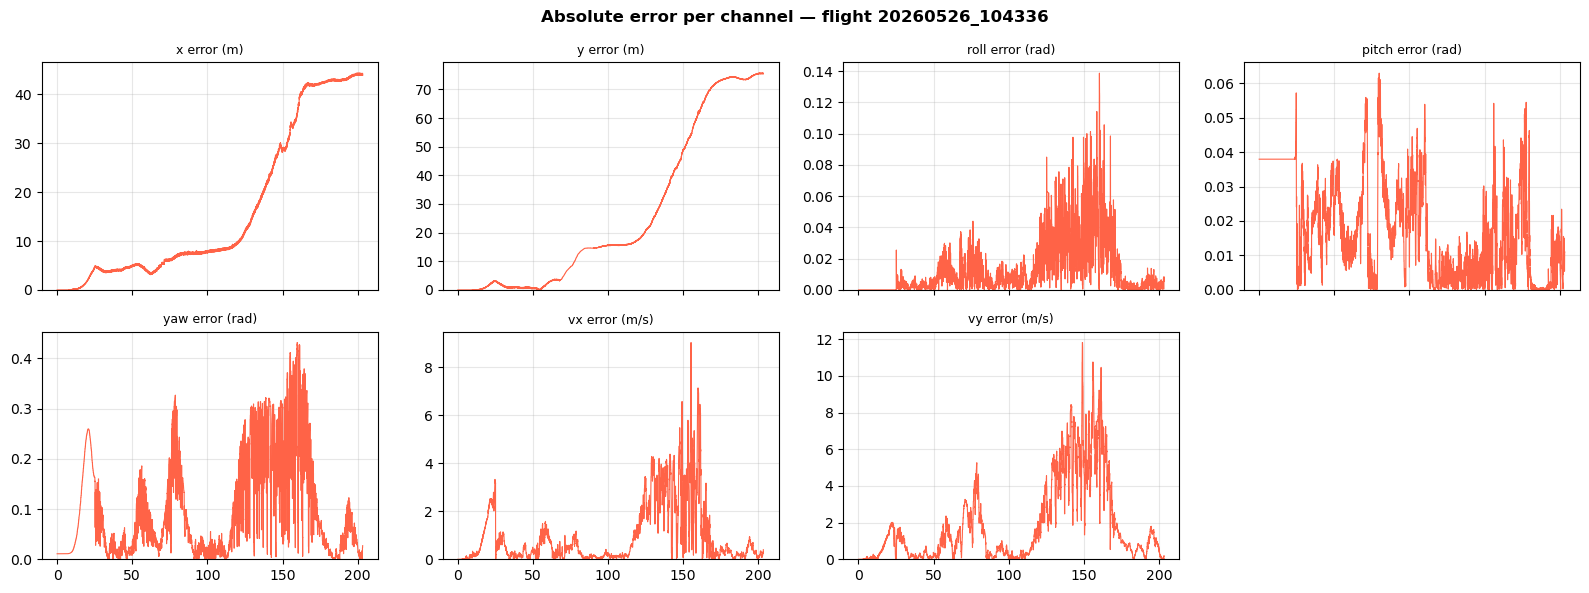

In [234]:
n_cols = len(GT_COLS)
ncols_plot = min(n_cols, 4)
nrows_plot = (n_cols + ncols_plot - 1) // ncols_plot
fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(4 * ncols_plot, 3 * nrows_plot), sharex=True)
axes_flat = np.array(axes).flat
for i, (col, unit) in enumerate(zip(GT_COLS, units)):
    ax = next(axes_flat)
    ax.plot(t, err[:, i], linewidth=0.8, color='tomato')
    ax.set_title(f'{col} error ({unit})', fontsize=9)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
for ax in axes_flat:
    ax.set_visible(False)
fig.suptitle(f'Absolute error per channel — flight {FLIGHT_ID}', fontweight='bold')
plt.tight_layout()
plt.show()

Fleet baseline (51 flights, MedAE — robust to landing wrap spikes):
  roll    fleet median=0.0037 rad (0.21°)  σ=0.0022 rad  warn>0.0070 rad  fail>0.0092 rad  abs floor fail=6°
  pitch   fleet median=0.0021 rad (0.12°)  σ=0.0015 rad  warn>0.0044 rad  fail>0.0059 rad  abs floor fail=6°
  yaw     fleet median=0.0333 rad (1.91°)  σ=0.0290 rad  warn>0.0769 rad  fail>0.1059 rad  abs floor fail=20°

Flight                              x        y       roll        yaw      vx      vy  Status
                                MedAE    MedAE   Med/RMSE   Med/RMSE     Med     Med
----------------------------------------------------------------------------------------------------
20260521_123357                 76.97   153.46   0.3/ 0.8°   3.7/10.3°   0.286   1.074  OK  
20260521_135938                176.32    19.16   0.2/ 0.4°   4.3/ 5.9°   0.454   1.221  OK  
20260521_142637                 19.84    74.74   0.2/ 0.5°   3.1/ 6.1°   0.416   0.345  OK  
20260521_211150                 28.15    35.0

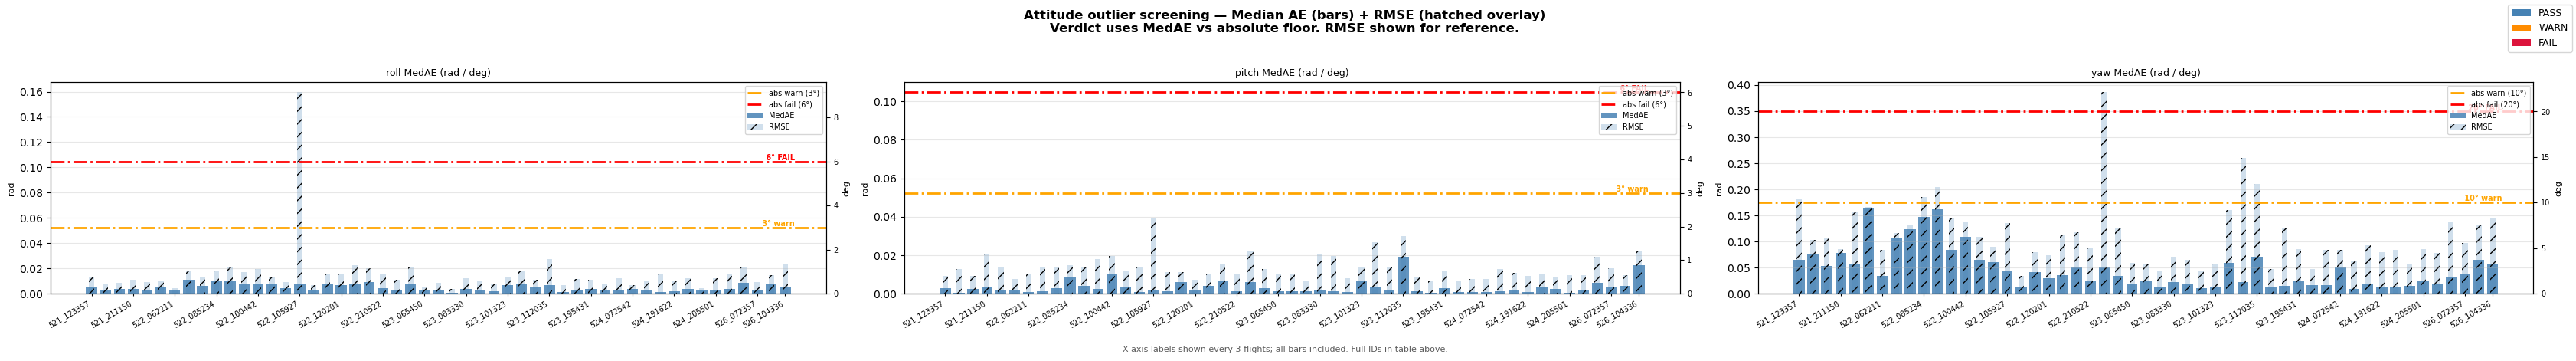

In [235]:
_EST_ALL    = ['x','y','z','roll','pitch','yaw','vx','vy','vz','p','q','r']
_ANGLE_COLS = {'roll', 'pitch', 'yaw'}

def _wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def _medae(e, g, col):
    """Median absolute error — robust to wrap spikes and landing outliers."""
    diff = e - g
    if col in _ANGLE_COLS:
        diff = _wrap(diff)
    return float(np.median(np.abs(diff)))

def _rmse(e, g, col):
    diff = e - g
    if col in _ANGLE_COLS:
        diff = _wrap(diff)
    return float(np.sqrt(np.mean(diff ** 2)))

SIGMA_WARN     = 1.5
SIGMA_FAIL     = 2.5
ABS_WARN_RAD   = {'roll': np.radians(3.0),  'pitch': np.radians(3.0),  'yaw': np.radians(10.0)}
ABS_FAIL_RAD   = {'roll': np.radians(6.0),  'pitch': np.radians(6.0),  'yaw': np.radians(20.0)}
_ATTITUDE_COLS = ['roll', 'pitch', 'yaw']
_VERDICT_COLOR = {'PASS': 'steelblue', 'WARN': 'darkorange', 'FAIL': 'crimson'}

_all_files = sorted(DATA_DIR.glob('marid_eskf_gt_flight_*.npz'))
_all_fids  = sorted(set(
    p.name.split('_chunk')[0].replace('marid_eskf_gt_flight_', '')
    for p in _all_files
))
_base_fids = [f for f in _all_fids if '_mirror' not in f]

rmse_table = []
for fid in _base_fids:
    cs = sorted(DATA_DIR.glob(f'marid_eskf_gt_flight_{fid}_chunk*.npz'))
    if not cs:
        continue
    e = np.concatenate([np.load(c, allow_pickle=True)['eskf_inputs'].astype(np.float32)  for c in cs])
    g = np.concatenate([np.load(c, allow_pickle=True)['pose_targets'].astype(np.float32) for c in cs])
    cols  = ['x','y','roll','pitch','yaw','vx','vy'] if g.shape[1] == 7 else ['x','y','z','roll','pitch','yaw','vx','vy','vz']
    eidx  = [_EST_ALL.index(c) for c in cols]
    medaes = [_medae(e[:, eidx[i]], g[:, i], cols[i]) for i in range(len(cols))]
    rmses  = [_rmse( e[:, eidx[i]], g[:, i], cols[i]) for i in range(len(cols))]
    rmse_table.append({'fid': fid, 'cols': cols, 'medaes': medaes, 'rmses': rmses})

if not rmse_table:
    print('No flight data found in', DATA_DIR)
else:
    fleet_median, fleet_mad = {}, {}
    for col in _ATTITUDE_COLS:
        vals = np.array([r['medaes'][r['cols'].index(col)] for r in rmse_table if col in r['cols']])
        med  = float(np.median(vals))
        mad  = float(np.median(np.abs(vals - med)) / 0.6745)
        fleet_median[col], fleet_mad[col] = med, max(mad, 1e-6)

    for r in rmse_table:
        worst = 'OK'
        for col in _ATTITUDE_COLS:
            if col not in r['cols']:
                continue
            val = r['medaes'][r['cols'].index(col)]
            z   = (val - fleet_median[col]) / fleet_mad[col]
            if   z > SIGMA_FAIL and val >= ABS_FAIL_RAD[col]: worst = 'BAD'
            elif z > SIGMA_WARN and val >= ABS_WARN_RAD[col] and worst != 'BAD': worst = 'WARN'
        r['verdict'] = {'BAD': 'FAIL', 'WARN': 'WARN', 'OK': 'PASS'}[worst]

    print(f"Fleet baseline ({len(rmse_table)} flights, MedAE — robust to landing wrap spikes):")
    for col in _ATTITUDE_COLS:
        print(f"  {col:6s}  fleet median={fleet_median[col]:.4f} rad ({np.degrees(fleet_median[col]):.2f}°)  "
              f"σ={fleet_mad[col]:.4f} rad  "
              f"warn>{fleet_median[col]+SIGMA_WARN*fleet_mad[col]:.4f} rad  "
              f"fail>{fleet_median[col]+SIGMA_FAIL*fleet_mad[col]:.4f} rad  "
              f"abs floor fail={np.degrees(ABS_FAIL_RAD[col]):.0f}°")
    print()

    print(f"{'Flight':<28}  {'x':>7}  {'y':>7}  {'roll':>9}  {'yaw':>9}  {'vx':>6}  {'vy':>6}  Status")
    print(f"{'':28}  {'MedAE':>7}  {'MedAE':>7}  {'Med/RMSE':>9}  {'Med/RMSE':>9}  {'Med':>6}  {'Med':>6}")
    print('-' * 100)
    for r in rmse_table:
        def _gm(col, _r=r): return _r['medaes'][_r['cols'].index(col)] if col in _r['cols'] else float('nan')
        def _gr(col, _r=r): return _r['rmses'][_r['cols'].index(col)]  if col in _r['cols'] else float('nan')
        tag = {'PASS': 'OK  ', 'WARN': 'WARN', 'FAIL': 'FAIL'}[r['verdict']]
        roll_str = f"{np.degrees(_gm('roll')):4.1f}/{np.degrees(_gr('roll')):4.1f}°"
        yaw_str  = f"{np.degrees(_gm('yaw')):4.1f}/{np.degrees(_gr('yaw')):4.1f}°"
        print(f"{r['fid'][-26:]:<28}  {_gm('x'):7.2f}  {_gm('y'):7.2f}  "
              f"{roll_str:>9}  {yaw_str:>9}  {_gm('vx'):6.3f}  {_gm('vy'):6.3f}  {tag}")

    bar_colors = [_VERDICT_COLOR[r['verdict']] for r in rmse_table]
    fids_plot  = [r['fid'] for r in rmse_table]
    x = np.arange(len(fids_plot))
    max_xtick_labels = 18
    tick_step = max(1, int(np.ceil(len(fids_plot) / max_xtick_labels)))
    tick_idx = np.arange(0, len(fids_plot), tick_step)
    if len(fids_plot) > 0 and tick_idx[-1] != len(fids_plot) - 1:
        tick_idx = np.append(tick_idx, len(fids_plot) - 1)
    tick_labels = [fids_plot[i][-10:] for i in tick_idx]

    fig_w = max(6 * len(_ATTITUDE_COLS), 0.22 * len(fids_plot) * len(_ATTITUDE_COLS))
    fig, axes = plt.subplots(1, len(_ATTITUDE_COLS), figsize=(fig_w, 4.6))
    for ax, col in zip(np.array(axes).flatten(), _ATTITUDE_COLS):
        vals_med  = [r['medaes'][r['cols'].index(col)] if col in r['cols'] else float('nan') for r in rmse_table]
        vals_rmse = [r['rmses'][r['cols'].index(col)]  if col in r['cols'] else float('nan') for r in rmse_table]
        ax.bar(x, vals_med,  color=bar_colors, alpha=0.85, label='MedAE')
        ax.bar(x, vals_rmse, color=bar_colors, alpha=0.25, width=0.4, label='RMSE', hatch='//')

        warn_y = ABS_WARN_RAD[col]
        fail_y = ABS_FAIL_RAD[col]
        ax.axhline(warn_y, color='orange', lw=2.0, ls='-.', label=f'abs warn ({np.degrees(warn_y):.0f}°)')
        ax.axhline(fail_y, color='red',    lw=2.0, ls='-.', label=f'abs fail ({np.degrees(fail_y):.0f}°)')
        ax.text(len(fids_plot) - 0.3, warn_y, f' {np.degrees(warn_y):.0f}° warn',
                color='orange', fontsize=7, va='bottom', ha='right', fontweight='bold')
        ax.text(len(fids_plot) - 0.3, fail_y, f' {np.degrees(fail_y):.0f}° FAIL',
                color='red',    fontsize=7, va='bottom', ha='right', fontweight='bold')

        ax.set_xticks(tick_idx)
        ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=7)
        ax.tick_params(axis='x', length=2)
        ax.set_title(f'{col} MedAE (rad / deg)', fontsize=9)
        ax.set_ylabel('rad', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, axis='y', alpha=0.3)

        ax_r = ax.twinx()
        y_lo, y_hi = ax.get_ylim()
        ax_r.set_ylim(np.degrees(y_lo), np.degrees(y_hi))
        ax_r.set_ylabel('deg', fontsize=8)
        ax_r.tick_params(axis='y', labelsize=7)

    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(facecolor='steelblue', label='PASS'),
                        Patch(facecolor='darkorange', label='WARN'),
                        Patch(facecolor='crimson',    label='FAIL')],
               loc='upper right', fontsize=9)
    fig.suptitle('Attitude outlier screening — Median AE (bars) + RMSE (hatched overlay)\n'
                 'Verdict uses MedAE vs absolute floor. RMSE shown for reference.',
                 fontweight='bold')
    if tick_step > 1:
        fig.text(0.5, 0.01, f'X-axis labels shown every {tick_step} flights; all bars included. Full IDs in table above.',
                 ha='center', fontsize=8, color='0.35')
    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    plt.show()
